In [1]:
%pip install -r ../requirements.txt


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/var/folders/xl/h46lcb3d74lfhd0gv6c3_n100000gn/T/ipykernel_49089/1565895237.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_medals', y='country', data=top10_df, palette='magma')


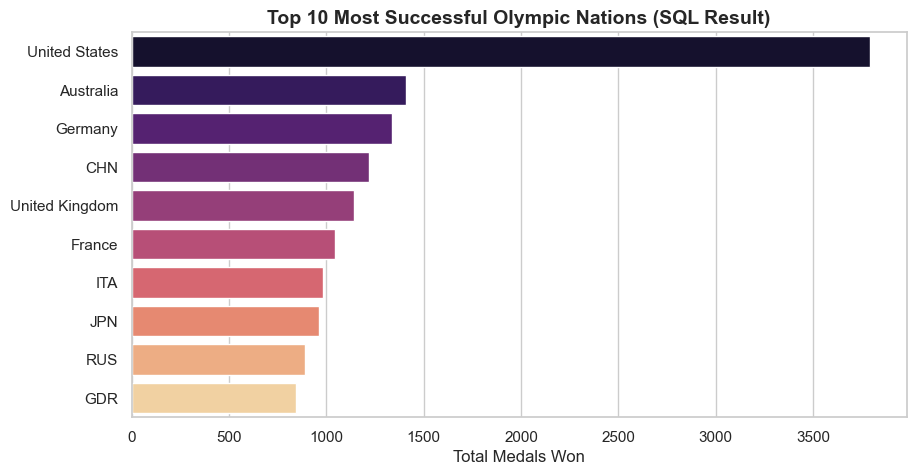

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Set visualization style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. TOP 10 COUNTRIES (SQL QUERY)
# ==========================================
# Connecting to the SQLite database generated by the pipeline
conn = sqlite3.connect("../data/processed/olympics.db")
query = """
SELECT country, SUM(medals_total) as total_medals
FROM olympics_final
GROUP BY country
ORDER BY SUM(medals_total) DESC
LIMIT 10;
"""
top10_df = pd.read_sql_query(query, conn)
conn.close()

plt.figure(figsize=(10, 5))
sns.barplot(x='total_medals', y='country', data=top10_df, palette='magma')
plt.title('Top 10 Most Successful Olympic Nations (SQL Result)', fontsize=14, fontweight='bold')
plt.xlabel('Total Medals Won')
plt.ylabel('')
plt.show()


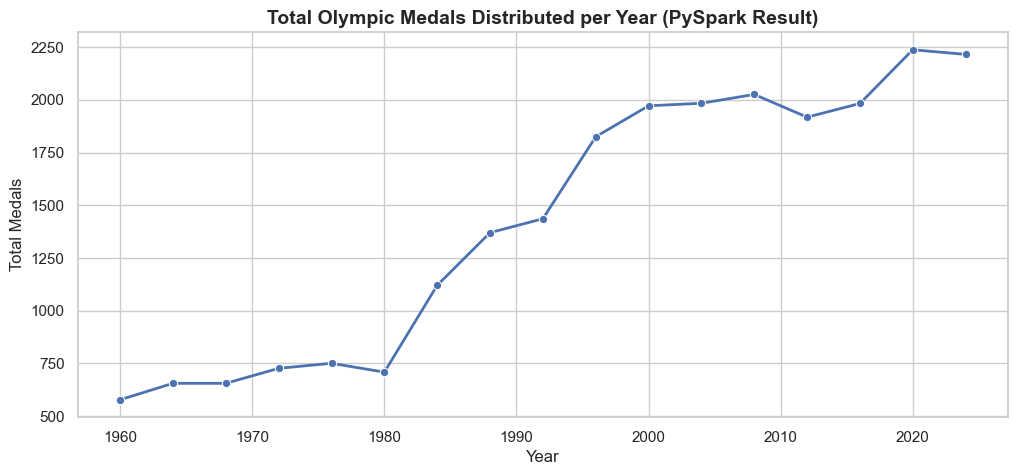

In [4]:
# ==========================================
# 2. MEDAL INFLATION OVER TIME (APACHE SPARK RESULT)
# ==========================================
# Reading the chronological data processed by PySpark
spark_df = pd.read_csv("../data/processed/medals_by_year.csv")

plt.figure(figsize=(12, 5))
sns.lineplot(x='year', y='sum(medals_total)', data=spark_df, marker='o', color='b', linewidth=2)
plt.title('Total Olympic Medals Distributed per Year (PySpark Result)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Medals')
plt.show()

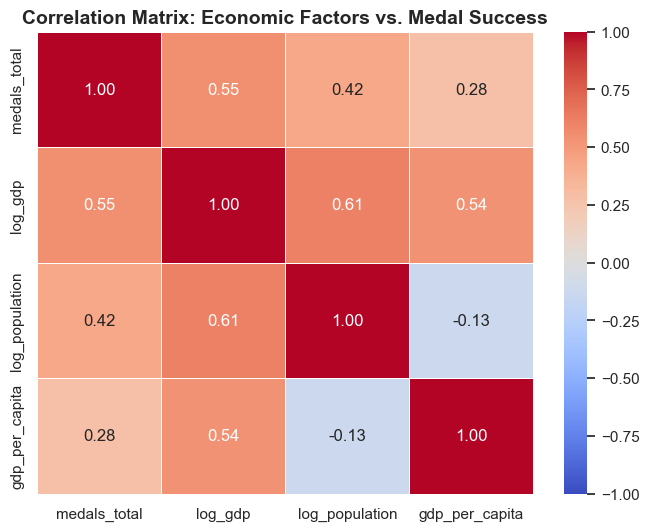

In [5]:
# ==========================================
# 3. MACROECONOMIC CORRELATION (WEALTH & POPULATION)
# ==========================================
final_df = pd.read_csv("../data/processed/final_dataset.csv")

# Using logarithmic values to balance extreme global disparities
econ_data = final_df[['medals_total', 'log_gdp', 'log_population', 'gdp_per_capita']]

plt.figure(figsize=(8, 6))
sns.heatmap(econ_data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix: Economic Factors vs. Medal Success', fontsize=14, fontweight='bold')
plt.show()

/var/folders/xl/h46lcb3d74lfhd0gv6c3_n100000gn/T/ipykernel_49089/706013471.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='host_flag', y='medals_total', data=host_comparison, palette='viridis')


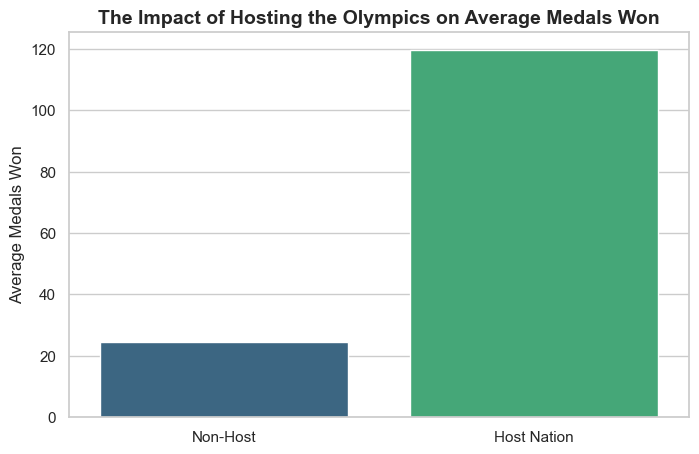

In [6]:
# ==========================================
# 4. THE HOST ADVANTAGE (ROI)
# ==========================================
host_comparison = final_df.groupby('host_flag')['medals_total'].mean().reset_index()
host_comparison['host_flag'] = host_comparison['host_flag'].map({0: 'Non-Host', 1: 'Host Nation'})

plt.figure(figsize=(8, 5))
sns.barplot(x='host_flag', y='medals_total', data=host_comparison, palette='viridis')
plt.title('The Impact of Hosting the Olympics on Average Medals Won', fontsize=14, fontweight='bold')
plt.ylabel('Average Medals Won')
plt.xlabel('')
plt.show()